In [ ]:
from __future__ import annotations

import os
import re
import pandas as pd
from collections import defaultdict
from itertools import combinations
from pathlib import Path
from rdkit import Chem

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from CGRtools.files import SMILESRead
from rdkit import Chem, RDLogger
from rdkit.Chem import ChiralType
from rxnsmiles2rinchi import RInChI

RDLogger.DisableLog('rdApp.*')

### E2SN2 dataset analysis

In [72]:
e2sn2_file = "https://raw.githubusercontent.com/hesther/reactiondatabase/main/data/e2sn2.csv"

### Some helper functions

In [44]:
def classify_reaction(aam: str) -> str:
    """Classify reaction as SN2 or E2, based on molecule count."""
    reactants, products = aam.split(">>")
    n_reactants = len(reactants.split("."))
    n_products = len(products.split("."))
    if n_reactants == 2 and n_products == 2:
        return "SN2"
    return "E2"



def remove_atom_map_and_canonicalize(smiles: str) -> str:
    """Remove atom map numbers and return canonical SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)


def get_ez_label(smiles: str) -> str | None:
    """Get E/Z label for the stereogenic double bond in a SMILES.

    Returns 'E', 'Z', or None if no stereogenic double bond is found.
    Uses RDKit's CIP-based assignment (atom map numbers are stripped first).
    """
    canon = remove_atom_map_and_canonicalize(smiles)
    mol = Chem.MolFromSmiles(canon)
    if mol is None:
        return None
    Chem.AssignStereochemistry(mol, cleanIt=True, force=True)

    for bond in mol.GetBonds():
        if bond.GetBondTypeAsDouble() != 2.0:
            continue
        stereo = bond.GetStereo()
        if stereo == Chem.BondStereo.STEREONONE:
            continue
        if stereo in (Chem.BondStereo.STEREOZ, Chem.BondStereo.STEREOCIS):
            return "Z"
        return "E"
    return None


def count_chiral_centers(aam: str) -> tuple[int, int]:
    """Count chiral centers in reactants and products.

    Returns (n_chiral_reactants, n_chiral_products).
    """
    reactants_str, products_str = aam.split(">>")
    counts = []
    for side in [reactants_str, products_str]:
        n_chiral = 0
        for part in side.split("."):
            mol = Chem.MolFromSmiles(part)
            if mol is not None:
                for atom in mol.GetAtoms():
                    tag = atom.GetChiralTag()
                    if tag in (ChiralType.CHI_TETRAHEDRAL_CW, ChiralType.CHI_TETRAHEDRAL_CCW):
                        n_chiral += 1
        counts.append(n_chiral)
    return counts[0], counts[1]


def get_canonical_2d_reaction(aam: str) -> str:
    """Strip atom map numbers and stereochemistry, return canonical reaction SMILES."""
    reactants_str, products_str = aam.split(">>")
    canonical_parts = []
    for side in [reactants_str, products_str]:
        mol_smiles = []
        for part in side.split("."):
            mol = Chem.MolFromSmiles(part)
            if mol is not None:
                # remove atom map numbers
                for atom in mol.GetAtoms():
                    atom.SetAtomMapNum(0)
                # remove stereochemistry (both chiral centers and E/Z)
                Chem.RemoveStereochemistry(mol)
                mol_smiles.append(Chem.MolToSmiles(mol))

        canonical_parts.append(".".join(sorted(mol_smiles)))
    return ">>".join(canonical_parts)


def _build_formula(symbols: list[str], root_symbol: str) -> str:
    """Build a functional-group formula: root atom first, then other heavy atoms, H last."""
    from collections import Counter
    counts = Counter(symbols)
    parts = []
    # root atom first
    if root_symbol in counts:
        parts.append(root_symbol + (str(counts[root_symbol]) if counts[root_symbol] > 1 else ''))
        del counts[root_symbol]
    # other heavy atoms alphabetically
    for elem in sorted(counts):
        if elem == 'H':
            continue
        parts.append(elem + (str(counts[elem]) if counts[elem] > 1 else ''))
        del counts[elem]
    # hydrogen last
    if 'H' in counts:
        parts.append('H' + (str(counts['H']) if counts['H'] > 1 else ''))
    return ''.join(parts)


def has_identical_residues_on_double_bond(smiles: str) -> bool:
    """Check if either C4 or C5 has two identical residues.

    For C4 (map 4): residues at maps 31, 41
    For C5 (map 5): residues at maps 11, 21
    Returns True if either (or both) carbon has two identical residue formulas.
    """
    params = Chem.SmilesParserParams()
    params.removeHs = False

    r_formulas = {}
    for part in smiles.split("."):
        mol = Chem.MolFromSmiles(part, params)
        if mol is None:
            continue

        map_to_idx = {}
        for atom in mol.GetAtoms():
            m = atom.GetAtomMapNum()
            if m != 0:
                map_to_idx[m] = atom.GetIdx()

        exclude = set()
        for c_map in [4, 5]:
            if c_map in map_to_idx:
                exclude.add(map_to_idx[c_map])

        for map_num in [11, 21, 31, 41]:
            if map_num not in map_to_idx:
                continue
            root_idx = map_to_idx[map_num]
            visited = {root_idx}
            queue = [root_idx]
            while queue:
                curr = queue.pop(0)
                for nb in mol.GetAtomWithIdx(curr).GetNeighbors():
                    nb_idx = nb.GetIdx()
                    if nb_idx not in visited and nb_idx not in exclude:
                        visited.add(nb_idx)
                        queue.append(nb_idx)
            root_symbol = mol.GetAtomWithIdx(root_idx).GetSymbol()
            symbols = [mol.GetAtomWithIdx(idx).GetSymbol() for idx in visited]
            r_formulas[map_num] = _build_formula(symbols, root_symbol)

    c5_same = r_formulas.get(11) == r_formulas.get(21)
    c4_same = r_formulas.get(31) == r_formulas.get(41)
    return c5_same or c4_same


def is_enantiomer_from_inchi(stereo1, stereo2):
    """Check if two stereochemistry strings represent enantiomers based on InChI extraction."""
    if len(stereo1) < 2 and len(stereo2) < 2:
        return True
    
    if (stereo1[0] == stereo2[0] and stereo1[1] == stereo2[1]) or (stereo1[0] != stereo2[0] and stereo1[1] != stereo2[1]):
        return True
    else: 
        return False


def get_smiles_cgr(rxn_smiles: str) -> str:
    """Return the SMILES/CGR of a given reaction SMILES."""
    parser = SMILESRead.create_parser(ignore=True)
    rxn_smiles = str(rxn_smiles)
    m = parser(rxn_smiles)
    m.explicify_hydrogens()

    try:
        return str(m.compose())
    except TypeError:
        return str(m)


# Regex matching SMILES atom tokens (bracket atoms, two-letter organic, single-letter organic)
_ATOM_TOKEN = re.compile(r"\[[^\]]+\]|Br|Cl|[BCNOPSFIbcnops*]")


def _inject_atom_maps(smi: str, maps_in_order: list[int]) -> str:
    """Insert atom map numbers into a canonical SMILES string."""
    atom_idx = 0

    def _replace(match: re.Match) -> str:
        nonlocal atom_idx
        token = match.group(0)
        map_num = maps_in_order[atom_idx]
        atom_idx += 1
        if not map_num:
            return token
        if token.startswith("["):
            # Bracket atom: insert `:N` before the closing `]`
            return f"{token[:-1]}:{map_num}]"
        # Organic subset atom: must bracketize to carry a map number.
        # (Fine when every atom is already bracketed, as in your data.)
        return f"[{token}:{map_num}]"

    return _ATOM_TOKEN.sub(_replace, smi)
    

def remove_atom_maps(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)
    

def _canonicalize_mapped(smi: str) -> str:
    mol = Chem.MolFromSmiles(smi, sanitize=False)
    if mol is None:
        raise ValueError(f"Cannot parse SMILES: {smi}")

    atom_maps: dict[int, int] = {}
    for atom in mol.GetAtoms():
        atom_maps[atom.GetIdx()] = atom.GetAtomMapNum()
        atom.SetAtomMapNum(0)

    can_smi = Chem.MolToSmiles(mol, canonical=True)

    # Fix: include private properties
    order = list(
        mol.GetPropsAsDict(includePrivate=True, includeComputed=True)[
            "_smilesAtomOutputOrder"
        ]
    )

    n = mol.GetNumAtoms()
    maps_in_order = [atom_maps[order[i]] for i in range(n)]
    res = _inject_atom_maps(can_smi, maps_in_order)
    res = remove_atom_maps(res)
    return res


def canonicalize_rxn(rxn: str) -> str:
    """Canonicalize a reaction SMILES so that structurally identical
    reactions get the same string (regardless of atom-map numbering)."""
    parts = rxn.split(">>")

    canonical_parts = [
        _canonicalize_mapped(p) if p else "" for p in parts
    ]
    
    return ">>".join(canonical_parts)

### Inchi-based tetrahedral-stereo-extractor class

In [45]:
class TetrahedralStereoExtractor:
    """Extract tetrahedral stereochemistry inforamtion from a reaction SMILES via its RInChI."""
    def __call__(self, rxn):
        """Extract tetrahedral stereo signs for reactant and product substrates.
        
        Args:
            rxn: Reaction SMILES string (with atom maps).
            
        Returns:
            (reactant_stereo, product_stereo) where each is a list of '+'/'-' 
            signs from the InChI /t layer, e.g. ['+', '-']. Empty list means 
            no tetrahedral stereocenters on the substrate.
        """
        rinchi = self._get_rinchi(rxn)
        layer1, layer2, layer3, _, layer5, _=self._extract_layers(rinchi=rinchi)
        assert "=" not in layer5, "This is an equilibrium, this class is not built for an equilibrium."
        
        reactants_layer, products_layer=(layer2, layer3)
        if "-" in layer5: 
            reactants_layer, products_layer=(layer3, layer2)

        substrate_reactant=self._get_substrate(reactants_layer)
        substrate_product=self._get_substrate(products_layer)
        tetr_reac = self._get_tetrahedral_stereochemistry_from_inchi(substrate_reactant)
        tetr_prod = self._get_tetrahedral_stereochemistry_from_inchi(substrate_product)
        
        return tetr_reac, tetr_prod

    def _get_rinchi(self, rxn_smi):
        """Convert reaction SMILES to RInChI string."""
        rinchi_tool = RInChI()
        rinchi, _ = rinchi_tool.rxn_smiles_to_rinchi_rinchikey(rxn_smi)
        return rinchi
        
    def _extract_layers(self, rinchi):
        """Split a RInChI string into its constituent layers.
        
        RInChI structure:
            layer1: header, e.g. "RInChI=1.00.1S/"
            layer2: first group of molecules (InChIs separated by '!')
            layer3: second group of molecules (after '<>')
            layer4: third group (agents, if present)
            layer5: direction layer /d ('+' or '-')
            layer6: uncertainty layer /u (if present)
        """
        layer1 = re.findall(r".+S/", rinchi)[0]
        layer4 = None
        try:
            layer2, layer3 = re.findall(r"(?<=(?:S/|<>)).+?(?=(?:<>|/d))", rinchi)
        except: layer2, layer3, layer4 = re.findall(r"(?<=(?:S/|<>)).+?(?=(?:<>|/d))", rinchi)
        try: 
            layer5 = re.findall(r"(?<=(?:/d)).+?(?=(?:/u|$))", rinchi)[0]
        except:
            layer5 = None
        try: 
            layer6 = re.findall(r"(?<=/u).+")
        except:
            layer6 = None
    
        return layer1, layer2, layer3, layer4, layer5, layer6
    
    def _get_tetrahedral_stereochemistry_from_inchi(self, inchi):
        """Parse the /t layer from an InChI to get tetrahedral stereo signs.
        
        Args:
            inchi: InChI string of a single molecule (one component from the RInChI).
            
        Returns:
            List of '+'/'-' signs, one per stereocenter. Empty list if achiral.
        """
        assert r"/s2" not in inchi, "Stereo type needs to be /s1 (absolute), but is /s2 (relative)"
        assert r"/s3" not in inchi, "Stereo type needs to be /s1 (absolute), but is /s3 (racemic)"
        t_layer_match = re.search(r"\/t(.+?)(?=\/|$)", inchi)
        tetrahedrals = []
        if t_layer_match:
            tetrahedrals = re.findall(r"[\+\-\=]", t_layer_match.group(1))
        return tetrahedrals
        
    def _get_substrate(self, layer):
        """Find the substrate (largest molecule by carbon count) in a RInChI layer."""
        molecules=layer.split("!")
        n_C=[]
        for molecule in molecules:
            try:            
                n_C.append(int(re.findall(r"(?<=C)\d+", molecule)[0]))
            except IndexError:
                n_C.append(0)
        assert any(n_C), "While looking for a substrate, could not find a molecule with carbon atoms"
        return molecules[np.argmax(n_C)]


### The main classification function:

Classifying pairs of reactions as:
- "same energy": expected to have same activation energy because the reactions are either idential or have enantiomeric TS
- "different energy": expected to have different activation energy

In [46]:
def classify_stereoisomer_energy(rxn_a: str, rxn_b: str, rxn_type: str, chiral_center_counts: tuple[int, int], ea_a, ea_b, row_a, row_b) -> str:
    """Compare two reactions with the same 2D structure.

    Returns 'same energy' or 'different energy'.
    """
    extractor = TetrahedralStereoExtractor()
    
    react_a, prod_a = rxn_a.split(">>")
    react_b, prod_b = rxn_b.split(">>")
    
    reac_identical = remove_atom_map_and_canonicalize(react_a) == remove_atom_map_and_canonicalize(react_b)
    prod_identical = remove_atom_map_and_canonicalize(prod_a) == remove_atom_map_and_canonicalize(prod_b)
        
    if reac_identical and prod_identical:
        # the reactions are identical, just differently ordered
        return "same energy"
    
    if rxn_type == "SN2":
        
        if chiral_center_counts in [(0, 0), (1, 0), (1, 1)]:
            return "same energy"

        # for groups (2, 1) and (2, 2) we need to investigate further.
        stereo_reac_a, stereo_prod_a = extractor(rxn_a)
        stereo_reac_b, stereo_prod_b = extractor(rxn_b)
        
        enantiomers_reac = is_enantiomer_from_inchi(stereo_reac_a, stereo_reac_b)
        enantiomers_prod = is_enantiomer_from_inchi(stereo_prod_a, stereo_prod_b)
        
        if chiral_center_counts == (2, 1):
            # products are always enantiomers
            assert enantiomers_prod 
            
            if enantiomers_reac:
                return "same energy"
            else:
                return "different energy"
        elif chiral_center_counts == (2, 2):
            if enantiomers_reac and enantiomers_prod:
                return "same energy"
            else:
                return "different energy"
        else:
            print("WARNING: unexpected case where one side is enantiomers.")

    elif rxn_type == "E2":
        prod_a = rxn_a.split(">>")[1]
        prod_b = rxn_b.split(">>")[1]
        
        if chiral_center_counts == (0, 0):
            return "same energy"
        elif chiral_center_counts == (1, 0):
            identical_res_a = has_identical_residues_on_double_bond(prod_a)
            identical_res_b = has_identical_residues_on_double_bond(prod_b)
            
            assert identical_res_a == identical_res_b
            if identical_res_a:
                return "same energy"
            
            ez_a = get_ez_label(prod_a)
            ez_b = get_ez_label(prod_b)
            if ez_a == ez_b:
                return "same energy"
            else:
                return "different energy"

        elif chiral_center_counts == (2, 0):
            ez_a = get_ez_label(rxn_a.split(">>")[1])
            ez_b = get_ez_label(rxn_b.split(">>")[1])
            if ez_a == ez_b:
                return "same energy"
            else:
                return "different energy"
            
    return f"WARNING: missed case for: rxn_type={rxn_type}, chiral_center_counts={chiral_center_counts}"

### Read the csv file and apply the preprocessing for the following classification to it

In [73]:
df = pd.read_csv(e2sn2_file)

df["rxn_type"] = df["AAM"].apply(classify_reaction)
df["canonical"] = df["AAM"].apply(canonicalize_rxn)
df["canonical_without_stereo"] = df["AAM"].apply(get_canonical_2d_reaction)
df[["n_chiral_reactants", "n_chiral_products"]] = (
    df["AAM"].apply(count_chiral_centers).apply(pd.Series)
)
df["SMILES/CGR"] = df["AAM"].apply(get_smiles_cgr)

In [74]:
# assign group ids to reactions with the same 2D structure
group_map = {}
group_id = 0
group_ids = []
for key in df["canonical_without_stereo"]:
    if key not in group_map:
        group_map[key] = group_id
        group_id += 1
    group_ids.append(group_map[key])
df["structure_group"] = group_ids

In [75]:
# show groups that have duplicates
group_counts = df["structure_group"].value_counts()
dup_groups = group_counts[group_counts > 1]
no_dup_groups = group_counts[group_counts == 1]

print(f"Total unique 2D structures: {len(group_map)}")
print(f"Groups with duplicates:     {len(dup_groups)}")
print(f"Groups without duplicates:  {len(no_dup_groups)}")
print()
print("Duplicate group sizes:")
print(dup_groups.value_counts().sort_index().rename("n_groups").rename_axis("group_size"))


Total unique 2D structures: 1942
Groups with duplicates:     1048
Groups without duplicates:  894

Duplicate group sizes:
group_size
2    609
3    243
4    196
Name: n_groups, dtype: int64


In [56]:
# for each group size, show breakdown by chiral center counts, split by rxn_type
df["group_size"] = df["structure_group"].map(group_counts)

for size, size_group in sorted(df.groupby("group_size")):
    print(f"\nGroup size {size} ({len(size_group)} groups):")
    for rxn_type, type_group in sorted(size_group.groupby("rxn_type")):
        chiral_key = list(zip(type_group["n_chiral_reactants"].astype(int), type_group["n_chiral_products"].astype(int)))
        chiral_counts = pd.Series(chiral_key).value_counts().sort_index()
        print(f"  {rxn_type} ({len(type_group)} groups):")
        for (nr, np_), count in chiral_counts.items():
            print(f"    chiral ({nr}, {np_}): {count}")


Group size 1 (894 groups):
  E2 (342 groups):
    chiral (0, 0): 96
    chiral (1, 0): 178
    chiral (2, 0): 68
  SN2 (552 groups):
    chiral (0, 0): 133
    chiral (1, 0): 43
    chiral (1, 1): 256
    chiral (2, 1): 14
    chiral (2, 2): 106

Group size 2 (1218 groups):
  E2 (436 groups):
    chiral (0, 0): 82
    chiral (1, 0): 250
    chiral (2, 0): 104
  SN2 (782 groups):
    chiral (0, 0): 96
    chiral (1, 0): 38
    chiral (1, 1): 430
    chiral (2, 1): 14
    chiral (2, 2): 204

Group size 3 (729 groups):
  E2 (234 groups):
    chiral (1, 0): 144
    chiral (2, 0): 90
  SN2 (495 groups):
    chiral (1, 0): 15
    chiral (1, 1): 228
    chiral (2, 1): 36
    chiral (2, 2): 216

Group size 4 (784 groups):
  E2 (252 groups):
    chiral (1, 0): 152
    chiral (2, 0): 100
  SN2 (532 groups):
    chiral (1, 0): 8
    chiral (1, 1): 232
    chiral (2, 1): 76
    chiral (2, 2): 216


In [57]:
import os
import re
import pandas as pd
from pathlib import Path
from rdkit import Chem

# Regex matching SMILES atom tokens (bracket atoms, two-letter organic, single-letter organic)
_ATOM_TOKEN = re.compile(r"\[[^\]]+\]|Br|Cl|[BCNOPSFIbcnops*]")


def _inject_atom_maps(smi: str, maps_in_order: list[int]) -> str:
    """Insert atom map numbers into a canonical SMILES string."""
    atom_idx = 0

    def _replace(match: re.Match) -> str:
        nonlocal atom_idx
        token = match.group(0)
        map_num = maps_in_order[atom_idx]
        atom_idx += 1
        if not map_num:
            return token
        if token.startswith("["):
            # Bracket atom: insert `:N` before the closing `]`
            return f"{token[:-1]}:{map_num}]"
        # Organic subset atom: must bracketize to carry a map number.
        # (Fine when every atom is already bracketed, as in your data.)
        return f"[{token}:{map_num}]"

    return _ATOM_TOKEN.sub(_replace, smi)


from rdkit import Chem

def remove_atom_maps(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol)
    

def _canonicalize_mapped(smi: str) -> str:
    mol = Chem.MolFromSmiles(smi, sanitize=False)
    if mol is None:
        raise ValueError(f"Cannot parse SMILES: {smi}")

    atom_maps: dict[int, int] = {}
    for atom in mol.GetAtoms():
        atom_maps[atom.GetIdx()] = atom.GetAtomMapNum()
        atom.SetAtomMapNum(0)

    can_smi = Chem.MolToSmiles(mol, canonical=True)

    # Fix: include private properties
    order = list(
        mol.GetPropsAsDict(includePrivate=True, includeComputed=True)[
            "_smilesAtomOutputOrder"
        ]
    )

    n = mol.GetNumAtoms()
    maps_in_order = [atom_maps[order[i]] for i in range(n)]
    res = _inject_atom_maps(can_smi, maps_in_order)
    res = remove_atom_maps(res)
    return res


def canonicalize_rxn(rxn: str) -> str:
    """Canonicalize a reaction SMILES so that structurally identical
    reactions get the same string (regardless of atom-map numbering)."""
    parts = rxn.split(">>")

    canonical_parts = [
        _canonicalize_mapped(p) if p else "" for p in parts
    ]
    
    return ">>".join(canonical_parts)

In [62]:
df["AAM"].nunique()

3625

In [61]:
df["canonical"].nunique()

3296

In [58]:
df["SMILES/CGR"].nunique()

1942

**Note** 👉
While the E2/SN2 dataset contains 3296 unique reactions, SMILES/CGR represents only 1942, as removal of stereochemistry and canonicalization collapse reactions with identical scaffolds into the same SMILES/CGR.

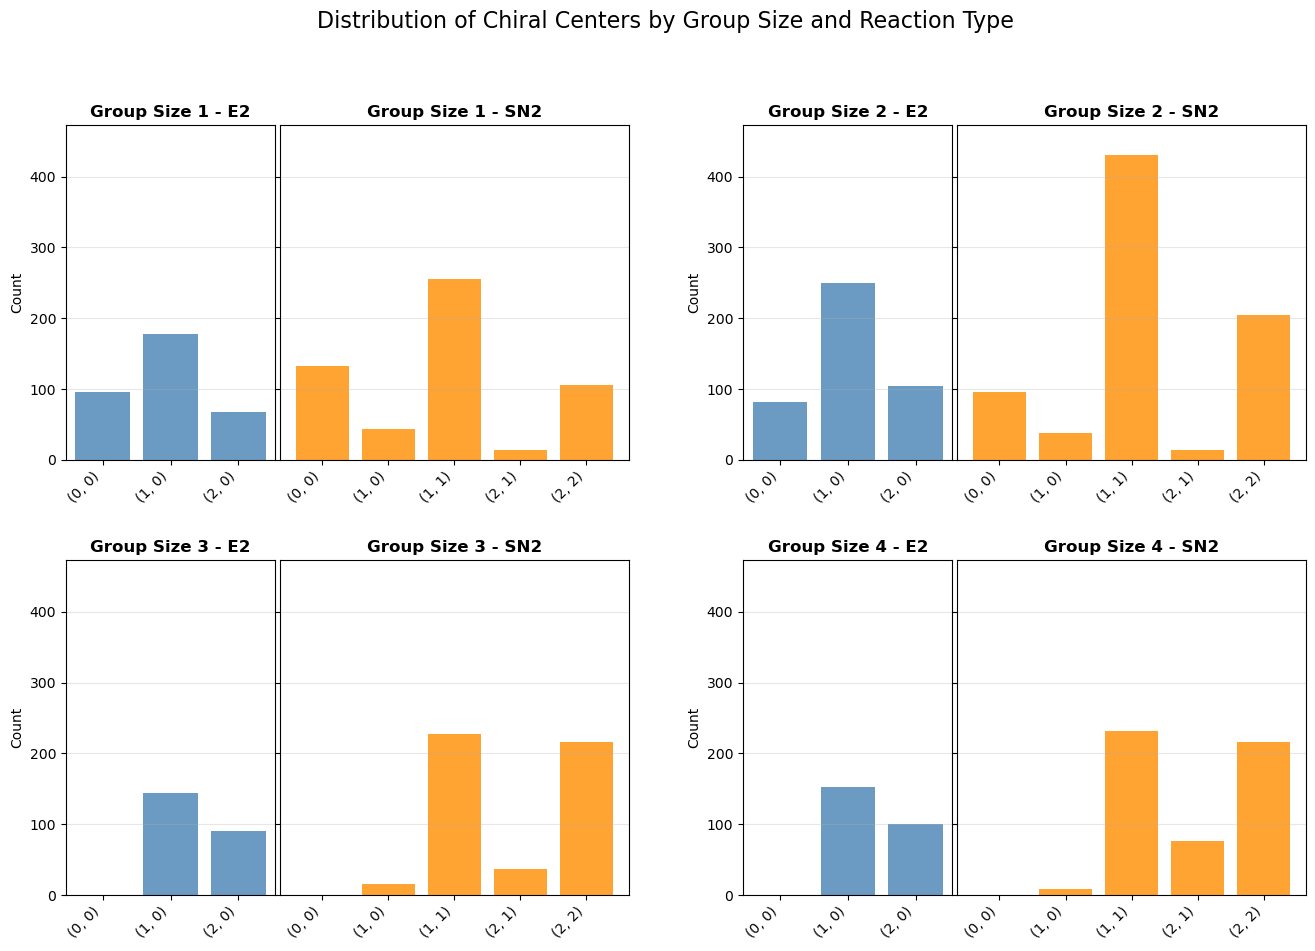

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# prepare data for visualization
viz_data = []
for size, size_group in sorted(df.groupby("group_size")):
    for rxn_type, type_group in sorted(size_group.groupby("rxn_type")):
        chiral_key = list(zip(type_group["n_chiral_reactants"].astype(int), type_group["n_chiral_products"].astype(int)))
        chiral_counts = pd.Series(chiral_key).value_counts().sort_index()
        for (nr, np_), count in chiral_counts.items():
            viz_data.append({
                "group_size": size,
                "rxn_type": rxn_type,
                "chiral": f"({nr}, {np_})",
                "count": count
            })

viz_df = pd.DataFrame(viz_data)

# define expected chiral centers for each reaction type
e2_chirals = ["(0, 0)", "(1, 0)", "(2, 0)"]
sn2_chirals = ["(0, 0)", "(1, 0)", "(1, 1)", "(2, 1)", "(2, 2)"]
chiral_map = {"E2": e2_chirals, "SN2": sn2_chirals}
colors = {"E2": "steelblue", "SN2": "darkorange"}

# get max count for consistent y-axis scaling
max_count = viz_df["count"].max()

# create plot
group_sizes = sorted(viz_df["group_size"].unique())

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 5, width_ratios=[0.6, 1, 0.3, 0.6, 1], hspace=0.3, wspace=0.02)

for row in range(2):
    for col_pair in range(2):
        size = group_sizes[row * 2 + col_pair]
        
        for j, rxn_type in enumerate(["E2", "SN2"]):
            # group 1: cols 0,1  | spacer: col 2 | group 2: cols 3,4
            col = col_pair * 3 + j
            ax = fig.add_subplot(gs[row, col])
            
            subset = viz_df[(viz_df["group_size"] == size) & (viz_df["rxn_type"] == rxn_type)]
            
            expected_chirals = chiral_map[rxn_type]
            counts_dict = dict(zip(subset["chiral"], subset["count"]))
            counts = [counts_dict.get(chiral, 0) for chiral in expected_chirals]
            
            ax.bar(expected_chirals, counts, color=colors[rxn_type], alpha=0.8)
            ax.set_title(f"Group Size {size} - {rxn_type}", fontweight="bold")
            ax.grid(axis="y", alpha=0.3)
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
            ax.set_ylim(0, max_count * 1.1)
            
            if rxn_type == "E2":
                ax.set_ylabel("Count")
            else:
                ax.set_yticklabels([])

plt.suptitle("Distribution of Chiral Centers by Group Size and Reaction Type", fontsize=16, y=0.995)
plt.show()

### Sanity check:

Within each canonical_2d group, chiral center counts should be the same

In [65]:
mismatches = []
for canonical_2d, group in df.groupby("canonical_without_stereo"):
    unique_chiral = group[["n_chiral_reactants", "n_chiral_products"]].drop_duplicates()
    if len(unique_chiral) > 1:
        mismatches.append((canonical_2d, len(group), unique_chiral.values.tolist()))

if mismatches:
    print(f"\nWARNING: {len(mismatches)} groups have inconsistent chiral center counts!")
    for canonical_2d, n, vals in mismatches[:10]:
        print(f"  {canonical_2d[:80]}... (n={n}): {vals}")
else:
    print("\nSanity check passed: all groups have consistent chiral center counts.")



Sanity check passed: all groups have consistent chiral center counts.


### Pairwise comparision within `canonical_without_stereo` groups, so where reaction pairs have the same 2D graphs, but might differ in 3D arrangement, and therefore might have either
- same energy (identical reactions)
- same energy (enantiomeric)
- different energy

In [66]:
# build pairwise comparisons for all duplicate groups
ea_diffs = defaultdict(list)  # key: (rxn_type, (n_chiral_react, n_chiral_prod), relationship)
pair_records = []
for i, (group_id, group) in enumerate(df[df["group_size"] > 1].groupby("structure_group")):
    indices = group.index.tolist()
    reactions = []
    for idx in indices:
        reactions.append(df.loc[idx, "AAM"])
    for idx_a, idx_b in combinations(indices, 2):
        rxn_type_a = df.loc[idx_a, "rxn_type"]
        rxn_type_b = df.loc[idx_b, "rxn_type"]
        ea_a = df.loc[idx_a, "ea"]
        ea_b = df.loc[idx_b, "ea"]
        assert rxn_type_a == rxn_type_b, "Mismatched rxn_type in same group!"

        chiral_centers_a = (df.loc[idx_a, "n_chiral_reactants"], df.loc[idx_a, "n_chiral_products"])
        chiral_centers_b = (df.loc[idx_b, "n_chiral_reactants"], df.loc[idx_b, "n_chiral_products"])
        assert chiral_centers_a == chiral_centers_b, "Mismatched chiral center counts in same group!"

        relationship = classify_stereoisomer_energy(
            df.loc[idx_a, "AAM"],
            df.loc[idx_b, "AAM"],
            rxn_type=rxn_type_a,
            chiral_center_counts=chiral_centers_a,
            ea_a=ea_a, 
            ea_b=ea_b,
            row_a=df.loc[idx_a],
            row_b=df.loc[idx_b]
        )
        pair_records.append({
            "idx_a": idx_a,
            "idx_b": idx_b,
            "structure_group": group_id,
            "rxn_type": df.loc[idx_a, "rxn_type"],
            "n_chiral_reactants": int(df.loc[idx_a, "n_chiral_reactants"]),
            "n_chiral_products": int(df.loc[idx_a, "n_chiral_products"]),
            "relationship": relationship,
        })
        chiral_key = (int(chiral_centers_a[0]), int(chiral_centers_a[1]))
        ea_diffs[(rxn_type_a, chiral_key, relationship)].append(abs(ea_a - ea_b))

pairs_df = pd.DataFrame(pair_records)
print(f"\nTotal pairwise comparisons: (total={len(pairs_df)})")
print(pairs_df["relationship"].value_counts())

print(f"\nSN2 pairwise comparisons: (total={len(pairs_df[pairs_df['rxn_type'] == 'SN2']['relationship'])})")
print(pairs_df[pairs_df["rxn_type"] == "SN2"]["relationship"].value_counts())


print(f"\nE2 pairwise comparisons: (total={len(pairs_df[pairs_df['rxn_type'] == 'E2']['relationship'])})")
print(pairs_df[pairs_df["rxn_type"] == "E2"]["relationship"].value_counts())
print()


print("\nEnergy differences by subgroup (for visualizations see next cell):")
for (rxn_type, chiral_key, relationship), diffs in sorted(ea_diffs.items()):
    arr = np.array(diffs)
    print()
    print(f"  {rxn_type} chiral{chiral_key} {relationship}: n={len(arr)} \n\tmean={arr.mean():.2f} ± {arr.std():.2f} (min={arr.min():.2f}, max={arr.max():.2f})")



Total pairwise comparisons: (total=2514)
relationship
same energy         1518
different energy     996
Name: count, dtype: int64

SN2 pairwise comparisons: (total=1684)
relationship
same energy         1152
different energy     532
Name: count, dtype: int64

E2 pairwise comparisons: (total=830)
relationship
different energy    464
same energy         366
Name: count, dtype: int64


Energy differences by subgroup (for visualizations see next cell):

  E2 chiral(0, 0) same energy: n=41 
	mean=2.48 ± 2.10 (min=0.03, max=10.60)

  E2 chiral(1, 0) different energy: n=273 
	mean=3.38 ± 3.87 (min=0.01, max=28.91)

  E2 chiral(1, 0) same energy: n=224 
	mean=3.69 ± 4.12 (min=0.00, max=32.61)

  E2 chiral(2, 0) different energy: n=191 
	mean=2.92 ± 2.96 (min=0.01, max=18.11)

  E2 chiral(2, 0) same energy: n=101 
	mean=2.95 ± 3.05 (min=0.00, max=20.06)

  SN2 chiral(0, 0) same energy: n=48 
	mean=3.12 ± 2.24 (min=0.01, max=9.89)

  SN2 chiral(1, 0) same energy: n=46 
	mean=2.63 ± 2.85 (min=0.

Same energy pairs (n=1518):       mean=3.41 ± 3.13
Different energy pairs (n=996):   mean=3.49 ± 3.34


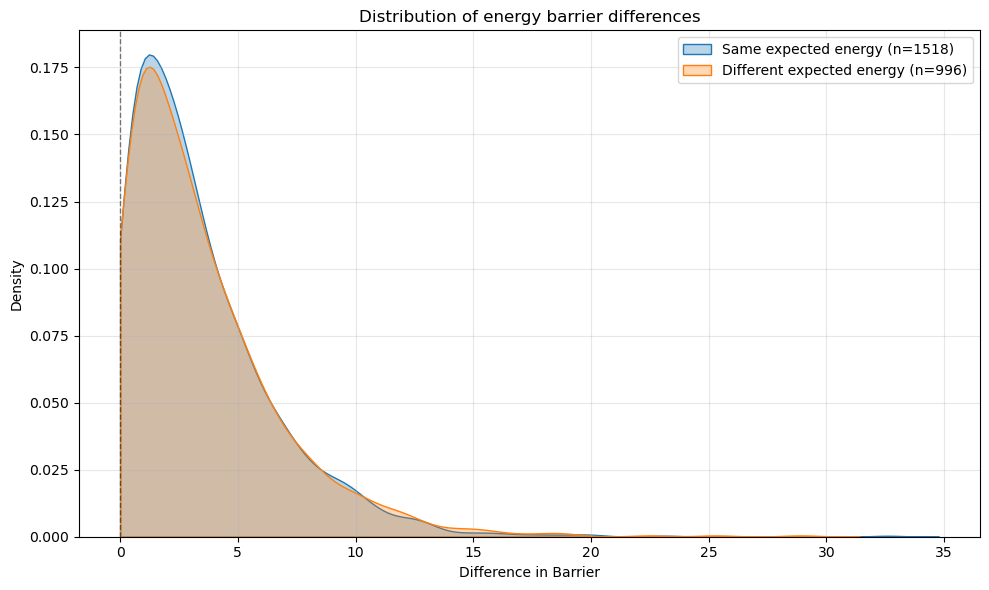

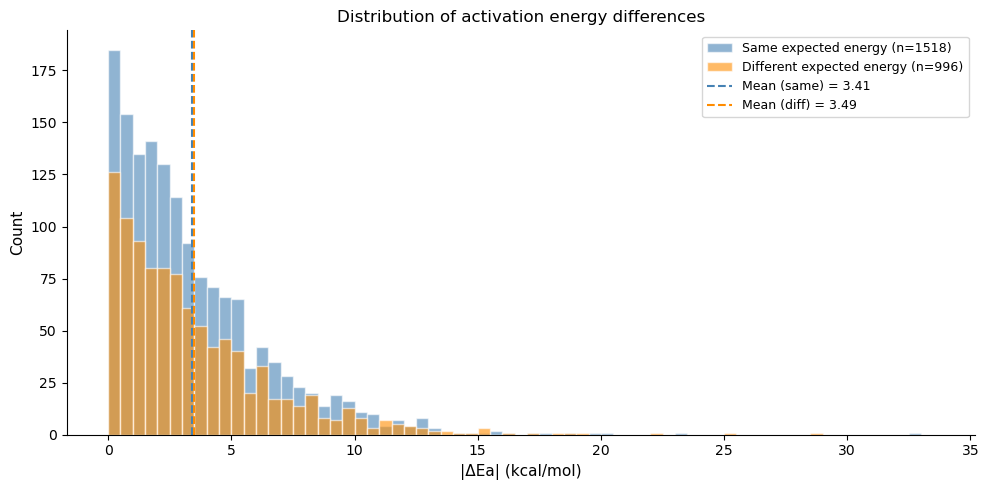

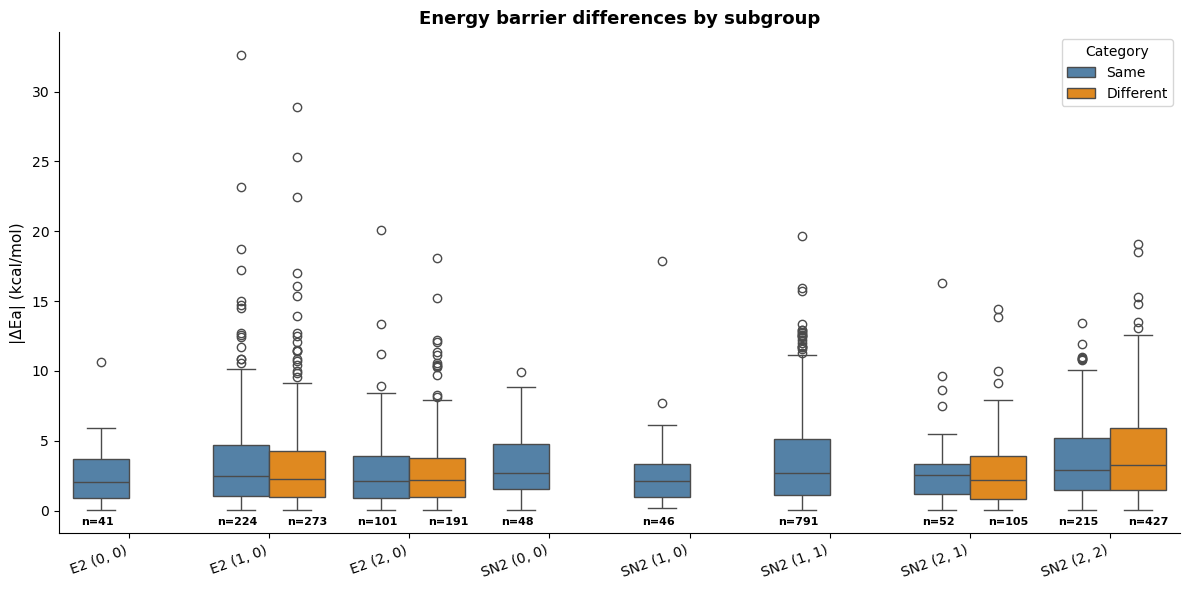

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

include_identical_in_plot = False
# all_identical_pairs = []
all_same_energy_diffs = []
all_diff_energy_diffs = []
for (rxn_type, chiral_key, relationship), diffs in ea_diffs.items():
    if "different" in relationship.lower():
        all_diff_energy_diffs.extend(diffs)
    elif "same" in relationship.lower():
        all_same_energy_diffs.extend(diffs)
    # else:
    #     all_identical_pairs.extend(diffs)
        

# print(f"\nIdentical pairs (n={len(all_identical_pairs)}):          mean={np.mean(all_identical_pairs):.2f} ± {np.std(all_identical_pairs):.2f}")
print(f"Same energy pairs (n={len(all_same_energy_diffs)}):       mean={np.mean(all_same_energy_diffs):.2f} ± {np.std(all_same_energy_diffs):.2f}")
print(f"Different energy pairs (n={len(all_diff_energy_diffs)}):   mean={np.mean(all_diff_energy_diffs):.2f} ± {np.std(all_diff_energy_diffs):.2f}")


fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(all_same_energy_diffs, clip=(0, None), ax=ax, label=f"Same expected energy (n={len(all_same_energy_diffs)})", fill=True, alpha=0.3)
sns.kdeplot(all_diff_energy_diffs, clip=(0, None), ax=ax, label=f"Different expected energy (n={len(all_diff_energy_diffs)})", fill=True, alpha=0.3)
# sns.kdeplot(all_identical_pairs, clip=(0, None), ax=ax, label=f"Identical pairs (n={len(all_identical_pairs)})", fill=True, alpha=0.3)

ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel("Difference in Barrier")
ax.set_ylabel("Density")
ax.set_title("Distribution of energy barrier differences")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Plot 2: Histogram — overlapping, same vs different
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(0, max(max(all_same_energy_diffs), max(all_diff_energy_diffs)) + 1, 0.5)
ax.hist(all_same_energy_diffs, bins=bins, alpha=0.6, color="steelblue", label=f"Same expected energy (n={len(all_same_energy_diffs)})", edgecolor="white")
ax.hist(all_diff_energy_diffs, bins=bins, alpha=0.6, color="darkorange", label=f"Different expected energy (n={len(all_diff_energy_diffs)})", edgecolor="white")
# ax.hist(all_identical_pairs, bins=bins, alpha=0.6, color="green", label=f"Same energy (n={len(all_identical_pairs)})", edgecolor="white")

ax.axvline(np.mean(all_same_energy_diffs), color="steelblue", linestyle="--", linewidth=1.5,label=f"Mean (same) = {np.mean(all_same_energy_diffs):.2f}")
ax.axvline(np.mean(all_diff_energy_diffs), color="darkorange", linestyle="--", linewidth=1.5,label=f"Mean (diff) = {np.mean(all_diff_energy_diffs):.2f}")
# ax.axvline(np.mean(all_identical_pairs), color="green", linestyle="--", linewidth=1.5,label=f"Mean (id.) = {np.mean(all_identical_pairs):.2f}")

ax.set_xlabel("|ΔEa| (kcal/mol)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Distribution of activation energy differences")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("plots/e2sn2_analysis.png")
plt.show()


# Plot 3: Per-subgroup box plots
subgroup_records = []
for (rxn_type, chiral_key, relationship), diffs in ea_diffs.items():
    cat = "Different" if "different" in relationship.lower() else "Same"
    label = f"{rxn_type} {chiral_key}"
    for d in diffs:
        subgroup_records.append({"Subgroup": label, "Category": cat, "|ΔEa|": d})
subgroup_df = pd.DataFrame(subgroup_records)

sorted_subgroups = sorted(subgroup_df["Subgroup"].unique())
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=subgroup_df, x="Subgroup", y="|ΔEa|", hue="Category", palette={"Same": "steelblue", "Different": "darkorange"}, order=sorted_subgroups, ax=ax)

# Annotate each box with pair count
hue_order = [h.get_text() for h in ax.get_legend().get_texts()]
n_hues = len(hue_order)
for i, subgroup in enumerate(sorted_subgroups):
    for j, cat in enumerate(hue_order):
        subset = subgroup_df[(subgroup_df["Subgroup"] == subgroup) & (subgroup_df["Category"] == cat)]
        if len(subset) == 0:
            continue
        x_pos = i - 0.45 * (n_hues - 1) / n_hues + j / n_hues
        y_pos = -1.5
        ax.text(x_pos, y_pos + 0.3, f"n={len(subset)}", ha="center", va="bottom",
                fontsize=8, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("|ΔEa| (kcal/mol)", fontsize=11)
ax.set_title("Energy barrier differences by subgroup", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("plots")
plt.show()

